<a href="https://colab.research.google.com/github/deltorobarba/astrophysics/blob/main/spectroscopy_infrared.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Infrared Astronomy**

Analyze spectral energy distribution (SED) of a star in the infrared range.(simulate some infrared photometry data and plot the SED)

In [3]:
!pip install astropy photutils astroquery -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 39.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 912.9/912.9 kB 28.9 MB/s eta 0:00:00


#### **Part 1**

Breaking News from the James Webb Space Telescope! Astronomers have discovered the first young brown dwarf candidates outside our Milky Way in the star cluster NGC 602! Located about 200,000 light-years away in the Small Magellanic Cloud, this stunning find offers a glimpse into star formation under early universe conditions. With incredible data from Webb’s NIRCam and MIRI instruments, we're uncovering secrets of the cosmos like never before!
Check out the breathtaking image and learn more about this groundbreaking discovery --> https://www.jameswebbdiscovery.com/discoveries/james-webb-telescope-discovers-first-brown-dwarf-outside-the-milky-way

Accessing data from the James Webb Space Telescope's (JWST) instruments, such as NIRCam and MIRI, through Astropy or Astroquery is possible, but not directly through the instruments themselves. You can retrieve the archival data associated with these instruments through the MAST (Mikulski Archive for Space Telescopes) interface provided by Astroquery.


In [6]:
from astroquery.mast import Observations

# Set up the query parameters
obs_table = Observations.query_criteria(
    obs_collection='JWST',           # Specific to JWST
    instrument_name=['NIRCam', 'MIRI']  # Query both NIRCam and MIRI
)

# Display the results
print(obs_table)

intentType obs_collection provenance_name instrument_name ... mtFlag srcDen   obsid     objID  
---------- -------------- --------------- --------------- ... ------ ------ --------- ---------
   science           JWST         CALJWST            MIRI ...  False    nan 102604820 215004479


In [ ]:
# Assuming you've selected specific observations (first one for this example)
data_products = Observations.get_product_list(obs_table[0])

# Download the data
Observations.download_products(data_products)

In [11]:
# Assuming you've selected specific observations (first one for this example)
data_products = Observations.get_product_list(obs_table[0])

# Download all data
#Observations.download_products(data_products)

# Show the available data products
print(data_products)

  obsID   obs_collection dataproduct_type ... dataRights calib_level filters
--------- -------------- ---------------- ... ---------- ----------- -------
 87595990           JWST            image ...     PUBLIC           1   P750L
 87595990           JWST            image ...     PUBLIC           1   P750L
 87595990           JWST            image ...     PUBLIC           1   P750L
 87595990           JWST            image ...     PUBLIC           1   P750L
 87595990           JWST            image ...     PUBLIC           1   P750L
 87595990           JWST            image ...     PUBLIC           1   P750L
 87595990           JWST            image ...     PUBLIC           1   P750L
 87595990           JWST            image ...     PUBLIC           1   P750L
 87595990           JWST            image ...     PUBLIC           1   P750L
 87595990           JWST            image ...     PUBLIC           1   P750L
      ...            ...              ... ...        ...         ...     ...

In [12]:
# Select the first few products to download (e.g., first 5 products)
selected_products = data_products[:5]  # Adjust the number as needed

# Download the selected data products
Observations.download_products(selected_products)

Local Path,Status,Message,URL
str102,str8,object,object
./mastDownload/JWST/jw01529004001_02101_00001_mirimage/jw01529004001_gs-acq1_2022191064946_stream.fits,COMPLETE,None,None
./mastDownload/JWST/jw01529004001_02101_00001_mirimage/jw01529004001_gs-acq1_2022191064946_uncal.fits,COMPLETE,None,None
./mastDownload/JWST/jw01529004001_02101_00001_mirimage/jw01529004001_gs-acq2_2022191064947_stream.fits,COMPLETE,None,None
./mastDownload/JWST/jw01529004001_02101_00001_mirimage/jw01529004001_gs-acq2_2022191064947_uncal.fits,COMPLETE,None,None
./mastDownload/JWST/jw01529004001_02101_00001_mirimage/jw01529004001_gs-fg_2022191070903_stream.fits,COMPLETE,None,None


In [13]:
# Inspect data

from astropy.io import fits

# Load the FITS file
file_path = './mastDownload/JWST/jw01529004001_02101_00001_mirimage/jw01529004001_gs-acq1_2022191064946_stream.fits'
hdul = fits.open(file_path)

# Inspect the structure of the FITS file (HDU List)
hdul.info()

Filename: ./mastDownload/JWST/jw01529004001_02101_00001_mirimage/jw01529004001_gs-acq1_2022191064946_stream.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     106   ()      
  1  SCI           1 ImageHDU        32   (128, 128, 12)   int16 (rescales to uint16)   


In [ ]:
#print(repr(hdul[0].header))  # Primary HDU header
#print(repr(hdul[1].header))  # Science data HDU header

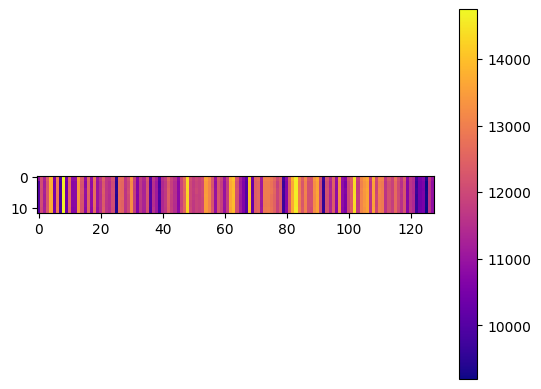

In [22]:
import matplotlib.pyplot as plt

# Plot the first image slice (for the first layer in the 3rd dimension)
plt.imshow(hdul[1].data[:, :, 0], cmap='plasma')
plt.colorbar()
plt.show()

In [14]:
# Access the primary header
primary_header = hdul[0].header
print(repr(primary_header))  # View primary header contents

SIMPLE  =                    T / Data conform to FITS standard                  
BITPIX  =                    8 / bits per data value                            
NAXIS   =                    0 / Number of axes                                 
EXTEND  =                    T / file may contain standard extensions           
NEXTEND =                    1 / Number of file extensions                      
DATE    = '2022-07-10T18:31:08' / UTC date file created                         
ORIGIN  = 'STSCI   '           / institution responsible for creating FITS file 
TIMESYS = 'UTC     '           / principal time system for time-related keywords
TIMEUNIT= 's       '           / Default unit applicable to all time values     
FILENAME= 'jw01529004001_gs-acq1_2022191064946_stream.fits' / Name of the file  
SDP_VER = '2022_2a '           / data processing software version number        
PRD_VER = 'PRDOPSSOC-055'      / S&OC PRD version number used in data processing
OSS_VER = '008.004.011.000' 

In [15]:
# Access the primary data (if available)
primary_data = hdul[0].data
print(primary_data)  # Will print the data array if it exists (might be large)

None


In [16]:
# If there are more extensions, you can explore them:
# Example: access extension 1's header and data
if len(hdul) > 1:
    extension_header = hdul[1].header
    print(repr(extension_header))

    extension_data = hdul[1].data
    print(extension_data)

XTENSION= 'IMAGE   '           / FITS extension type                            
BITPIX  =                   16 / bits per data value                            
NAXIS   =                    3 / Number of axes                                 
NAXIS1  =                  128 / Size of the axis                               
NAXIS2  =                  128 / Size of the axis                               
NAXIS3  =                   12 / Size of the axis                               
PCOUNT  =                    0 / number of parameter bytes following data table 
GCOUNT  =                    1 / number of groups                               
BSCALE  =                  1.0 / scale factor for array value to physical value 
BZERO   =                32768 / physical value for an array value of zero      
BUNIT   = 'DN      '           / physical units of the data array values        
EXTNAME = 'SCI     '           / EXTNAME of the extension containing image      
RADESYS = 'ICRS    '        

In [ ]:
# Close the FITS file when done
hdul.close()

#### **Part 2**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from astropy import constants as const
from astropy import units as u

# Constants
wavelengths = np.linspace(1, 20, 500) * u.micron  # Wavelength range in infrared
temperature = 3000 * u.K  # Example temperature of the star
radius = 1 * u.Rsun  # Solar radius for the star's radius
distance = 10 * u.pc  # Distance to the star

# Planck's law to calculate the spectral radiance per unit wavelength
def planck_law(wavelength, T):
    """Return the blackbody spectral radiance for a given wavelength and temperature."""
    h = const.h  # Planck's constant
    c = const.c  # Speed of light
    k_B = const.k_B  # Boltzmann constant

    numerator = 2.0 * h * c**2 / wavelength**5
    exponent = np.exp((h * c) / (wavelength * k_B * T)) - 1.0
    radiance = numerator / exponent  # Spectral radiance

    return radiance.to(u.W / (u.m**2 * u.micron * u.sr))

# Calculate the flux density using Planck's law
flux_density_per_wavelength = planck_law(wavelengths, temperature)

# Convert to flux (remove steradian by multiplying with solid angle subtended by the star)
solid_angle = np.pi * (radius / distance)**2
flux_density = flux_density_per_wavelength * solid_angle

# Convert flux density to the desired units: W / (m² * µm)
flux_density = flux_density.to(u.W / (u.m**2 * u.micron))

# Plotting the Spectral Energy Distribution (SED)
plt.figure(figsize=(8, 6))
plt.plot(wavelengths, flux_density, color='orange', label=f'Star with T={temperature:.0f}K')

# Label the plot
plt.title('Spectral Energy Distribution in the Infrared')
plt.xlabel('Wavelength (µm)')
plt.ylabel('Flux Density (W / m² / µm)')
plt.legend()
plt.grid(True)

plt.show()


* **Wavelength Range**: The wavelength range is set in microns to cover the infrared range, typically 1–20 microns.
* **Blackbody Radiation**: The blackbody radiation is used to calculate the spectral energy distribution, based on the temperature and radius of the star.
* **Plot**: The result is a plot of flux density versus wavelength, showing how the radiation behaves in the infrared spectrum for the given temperature.

Planck's law to compute the flux density of a blackbody directly as a function of wavelength. Planck equation for blackbody radiation:

Planck’s Law in Wavelength Form:

$
B(\lambda, T) = \frac{2hc^2}{\lambda^5} \cdot \frac{1}{e^{hc / (\lambda k_B T)} - 1}
$

Where:
- $ B(\lambda, T) $ is the spectral radiance as a function of wavelength and temperature.
- $ \lambda $ is the wavelength.
- \( T \) is the temperature.
- \( h \) is Planck’s constant.
- \( c \) is the speed of light.
- \( k_B \) is Boltzmann’s constant.

Calculate flux density.

1. **Planck’s Law**: We manually calculate the blackbody radiance using Planck’s law in the wavelength domain.
2. **Solid Angle**: The radiance is multiplied by the solid angle subtended by the star, given by \((\text{radius}/\text{distance})^2\), to get the flux density at Earth.
3. **Unit Compatibility**: This approach avoids the unit conversion issues, as all calculations are done with the correct unit handling.

This method should now work without triggering any unit conversion errors and will generate the spectral energy distribution in the infrared range!

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.constants import h, k, c

def blackbody_lam(lam, T):
  """
  Blackbody radiation as a function of wavelength (um) and temperature (K).
  Returns units of erg/s/cm^2/cm/Steradian
  """
  lam = 1e-6 * lam  # convert to meters
  return 2 * h * c**2 / (lam**5 * (np.exp(h * c / (lam * k * T)) - 1))

# Load your spectral data (replace with your actual data)
data = np.loadtxt("spectral_data.txt")
wavelength = data[:, 0]  # Wavelength in microns
flux = data[:, 1]       # Flux in erg/s/cm^2/cm/Steradian

# Initial guess for temperature
initial_guess = 5000

# Perform the curve fit
popt, pcov = curve_fit(blackbody_lam, wavelength, flux, p0=initial_guess)

# Extract the fitted temperature
T_fit = popt[0]

# Calculate the blackbody curve with the fitted temperature
blackbody_fit = blackbody_lam(wavelength, T_fit)

# Plot the results
plt.figure()
plt.plot(wavelength, flux, 'o', label="Observed Data")
plt.plot(wavelength, blackbody_fit, '-', label="Blackbody Fit (T = {:.0f} K)".format(T_fit))
plt.xlabel('Wavelength (microns)')
plt.ylabel('Flux (erg/s/cm^2/cm/Steradian)')
plt.legend()
plt.show()

print("Fitted Temperature: {:.0f} K".format(T_fit))

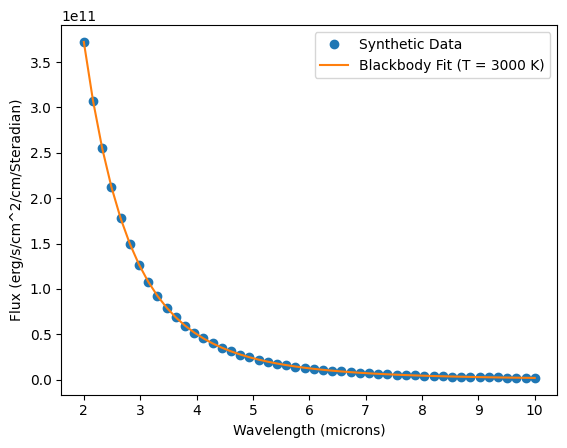

Actual Temperature: 3000 K
Fitted Temperature: 3000 K


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.constants import h, k, c

def blackbody_lam(lam, T):
  """
  Blackbody radiation as a function of wavelength (um) and temperature (K).
  Returns units of erg/s/cm^2/cm/Steradian
  """
  lam = 1e-6 * lam  # convert to meters
  return 2 * h * c**2 / (lam**5 * (np.exp(h * c / (lam * k * T)) - 1))

# Generate synthetic spectral data (example)
wavelength = np.linspace(2, 10, 50)  # Wavelength in microns
T_actual = 3000  # Actual temperature of the blackbody
noise = np.random.normal(0, 1e-8, size=len(wavelength))  # Add some noise
flux = blackbody_lam(wavelength, T_actual) + noise

# Initial guess for temperature
initial_guess = 4000

# Perform the curve fit
popt, pcov = curve_fit(blackbody_lam, wavelength, flux, p0=initial_guess)

# Extract the fitted temperature
T_fit = popt[0]

# Calculate the blackbody curve with the fitted temperature
blackbody_fit = blackbody_lam(wavelength, T_fit)

# Plot the results
plt.figure()
plt.plot(wavelength, flux, 'o', label="Synthetic Data")
plt.plot(wavelength, blackbody_fit, '-', label="Blackbody Fit (T = {:.0f} K)".format(T_fit))
plt.xlabel('Wavelength (microns)')
plt.ylabel('Flux (erg/s/cm^2/cm/Steradian)')
plt.legend()
plt.show()

print("Actual Temperature: {:.0f} K".format(T_actual))
print("Fitted Temperature: {:.0f} K".format(T_fit))

- Define blackbody function (`blackbody_lam`): Takes wavelength (`lam` in microns) and temperature (`T` in Kelvin) as input. Calculates blackbody radiation using Planck's law. Returns the spectral radiance in units of erg/s/cm^2/cm/Steradian.
- Load spectral data in `"spectral_data.txt"`. Assumes data file has two columns: wavelength (in microns) and flux (in erg/s/cm^2/cm/Steradian)
- Provide `initial_guess` for the temperature, set to 5000 K
- Perform curve fit using `curve_fit` to find best-fit parameters (in this case, the temperature) for the `blackbody_lam` function to match your data. `popt` stores the optimal values of the fitted parameters. `pcov` is the covariance matrix of the parameters.
- Extract fitted temperature: `T_fit = popt[0]` get fitted temperature from the `popt` array.
- Calculate the fitted blackbody curve: use fitted temperature (`T_fit`) to generate the blackbody curve.
- Plots the observed data and the fitted blackbody curve.
- Displays the best-fit temperature value.

**Analyze Spitzer IRAC images**

In [ ]:
from astropy.io import fits
from astropy.visualization import astropy_mpl_style
import matplotlib.pyplot as plt
from photutils.aperture import CircularAperture, aperture_photometry
from photutils.background import Background2D, MedianBackground

# Set Matplotlib style to Astropy
plt.style.use(astropy_mpl_style)

# Load the Spitzer IRAC image (replace with your actual file)
image_file = 'irac_image.fits'
hdul = fits.open(image_file)
image_data = hdul[0].data

# Display basic information about the image
print(hdul.info())

# Show the image
plt.figure()
plt.imshow(image_data, cmap='gray', origin='lower')
plt.colorbar()
plt.title('Spitzer IRAC Image')
plt.xlabel('Pixel X')
plt.ylabel('Pixel Y')
plt.show()

# Perform simple aperture photometry
# Define the aperture (adjust position and radius as needed)
positions = [(100, 100)]  # Example position for a source
apertures = CircularAperture(positions, r=5)  # Example aperture radius

# Estimate the background
bkg_estimator = MedianBackground()
bkg = Background2D(image_data, (50, 50), filter_size=(3, 3), bkg_estimator=bkg_estimator)

# Perform aperture photometry
phot_table = aperture_photometry(image_data - bkg.background, apertures)

# Print the photometry results
print(phot_table)

# Close the FITS file
hdul.close()